### Notebook de testes para encontrar o melhor backtest do modelo

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import bs4 as bs
import seaborn as sns
import requests
import time

from funcoes2 import (
    pca_portfolio_spy,
    pca_portfolio_spy_hedge,
    stats_from_returns,
    pca_portfolio_spy_adaptive_pcs,
    pca_portfolio_spy_var
)

from analise_estrategia import analyze_strategy 

In [2]:
# Carregar dados
start_date = "1997-01-02"
end_date = "2007-12-31"

data = pd.read_csv("dados_full_1997_2007.csv", index_col=0)
#data = pd.read_csv("dados_1997_2025.csv", index_col=0)
data.index = pd.to_datetime(data.index)
data = data.sort_index()

returns = data.pct_change()
returns.dropna(inplace=True,axis=0, how='all')
returns.dropna(inplace=True,axis=1, how='any')
returns = returns.loc[start_date:end_date]

# Baixar dados do SPY para o mesmo período
data_spy = yf.download("SPY", start=start_date, end=end_date, auto_adjust=True)["Close"]
data_spy.index = pd.to_datetime(data_spy.index)
data_spy = data_spy.sort_index()
returns_spy = data_spy.pct_change()
returns_spy.dropna(inplace=True)

# Garantir que ambos os DataFrames tenham índices coerentes e ordenados (sem timezone)
returns.index     = pd.to_datetime(returns.index).tz_localize(None)
returns_spy.index = pd.to_datetime(returns_spy.index).tz_localize(None)
returns     = returns.sort_index()
returns_spy = returns_spy.sort_index()

[*********************100%***********************]  1 of 1 completed


In [3]:
# pegar os tickers e atualizar os dados até 2025
tickers = data.columns.tolist()
len(tickers)

417

In [4]:
# verificando dados ruins
bad_tickers = []

for col in data.columns:
    p = data[col]
    if p.min() <= 0:
        bad_tickers.append(col)
        continue
    if (p.max() / p.min()) > 1e3:  # variação absurda de escala
        bad_tickers.append(col)

data = data.drop(columns=bad_tickers, errors="ignore")
returns = returns.drop(columns=bad_tickers, errors="ignore")

bad_tickers

[]

In [5]:
returns.head()

,MMM,AOS,ABT,ADBE,AMD,AES,AFL,APD,ALB,LNT,...,WEC,WFC,WELL,WST,WDC,WY,WSM,WMB,XEL,ZBRA
Date,,,,,,,,,,,,,,,,,,,,,
1997-01-03,-0.017392,-0.008404,0.022333,0.012945,0.032258,-0.002754,0.002915,0.016513,-0.019608,0.004464,...,0.004673,0.020232,0.015544,-0.004465,0.043280,0.000000,0.037838,0.017182,0.002732,0.037634
1997-01-06,0.001476,-0.012712,-0.012136,0.035144,0.017857,0.027624,0.011628,0.005415,0.020000,0.004444,...,0.004651,-0.011332,-0.005103,-0.004484,0.043668,0.013263,-0.059028,0.013513,0.005449,0.015544
1997-01-07,-0.011783,0.030043,0.022112,0.040124,0.048246,0.010752,-0.005747,-0.003590,-0.006536,-0.004424,...,0.000000,0.011462,-0.010256,0.009009,-0.004184,0.013089,0.029521,0.020000,0.005421,0.091837
1997-01-08,-0.001490,-0.004167,-0.014423,0.002967,-0.033473,0.007979,0.005780,0.005405,-0.019736,0.000000,...,0.009259,0.005666,-0.010363,-0.008929,0.039916,0.007751,-0.021506,0.009804,0.010782,-0.018692
1997-01-09,-0.001493,-0.004183,0.009757,-0.020710,-0.047619,0.002638,-0.008621,-0.001792,0.013422,0.004444,...,0.018349,0.000000,0.020942,0.000000,0.020202,-0.002564,0.069597,0.019418,0.002666,0.038095


Tempo : 1999-03-29 00:00:00
Tempo : 1999-03-30 00:00:00
Tempo : 1999-03-31 00:00:00
Tempo : 1999-04-01 00:00:00
Tempo : 1999-04-05 00:00:00
Tempo : 1999-04-06 00:00:00
Tempo : 1999-04-07 00:00:00
Tempo : 1999-04-08 00:00:00
Tempo : 1999-04-09 00:00:00
Tempo : 1999-04-12 00:00:00
Tempo : 1999-04-13 00:00:00
Tempo : 1999-04-14 00:00:00
Tempo : 1999-04-15 00:00:00
Tempo : 1999-04-16 00:00:00
Tempo : 1999-04-19 00:00:00
Tempo : 1999-04-20 00:00:00
Tempo : 1999-04-21 00:00:00
Tempo : 1999-04-22 00:00:00
Tempo : 1999-04-23 00:00:00
Tempo : 1999-04-26 00:00:00
Tempo : 1999-04-27 00:00:00
Tempo : 1999-04-28 00:00:00
Tempo : 1999-04-29 00:00:00
Tempo : 1999-04-30 00:00:00
Tempo : 1999-05-03 00:00:00
Tempo : 1999-05-04 00:00:00
Tempo : 1999-05-05 00:00:00
Tempo : 1999-05-06 00:00:00
Tempo : 1999-05-07 00:00:00
Tempo : 1999-05-10 00:00:00
Tempo : 1999-05-11 00:00:00
Tempo : 1999-05-12 00:00:00
Tempo : 1999-05-13 00:00:00
Tempo : 1999-05-14 00:00:00
Tempo : 1999-05-17 00:00:00
Tempo : 1999-05-18 0

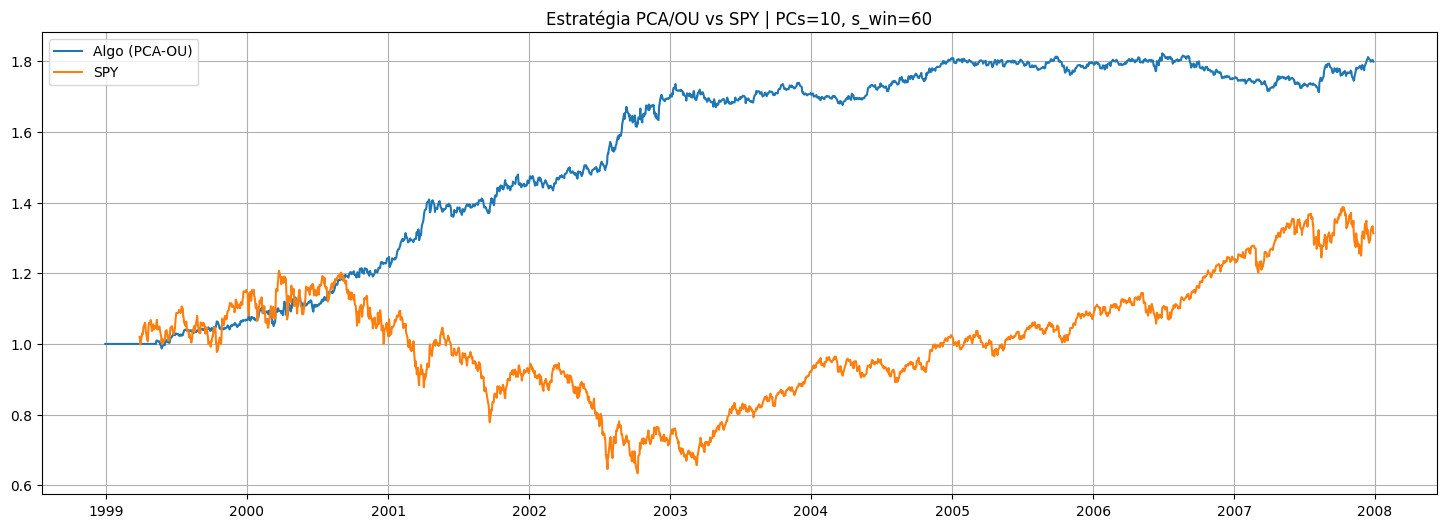

In [7]:
# Melhor
returns0 = returns.loc["1998-12-30":"2007-12-28"]
returns_spy0 = returns_spy.loc["1998-12-30":"2007-12-28"]

# Rodar experimento 03 : (n = 10, sbo=1.25, sso=1.25, sbc=0.50, ssc=0.50, rebalanceamento_dias = 1) (padronizado)
results = pca_portfolio_spy(
    returns=returns0,
    returns_spy=returns_spy0,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True
)

In [ ]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net = results['ret_net']
stats = stats_from_returns(ret_net)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2007)")
print("="*70)
for k, v in stats.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")

# =============================================================================
# 4. ANÁLISE DE NEUTRALIDADE ⭐ NOVO
# =============================================================================

analysis_results = analyze_strategy(
    algo_weights=results['algo_weights'],
    betas=results['betas'],
    ret_net=results['ret_net'],
    Factor_PCA=results['Factor_PCA'],
    pcs=results['pcs'],
    plot=True,
    title_prefix="[1999-2007] "
)

# =============================================================================
# 5. ANÁLISE POR SUBPERÍODOS (OPCIONAL)
# =============================================================================

print("\n" + "📅 "*35)
print("ANÁLISE POR SUBPERÍODOS")
print("📅 "*35 + "\n")

subperiods = [
    ("1999-2002", "1999-01-01", "2002-12-31"),
    ("2003-2007", "2003-01-01", "2007-12-31"),
]

for label, start, end in subperiods:
    print(f"\n{'='*70}")
    print(f"Subperíodo: {label}")
    print(f"{'='*70}")
    
    mask = (ret_net.index >= start) & (ret_net.index <= end)
    ret_sub = ret_net[mask]
    
    if len(ret_sub) < 100:
        print("⚠️  Dados insuficientes")
        continue
    
    stats_sub = stats_from_returns(ret_sub)
    for k, v in stats_sub.items():
        print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")

Tempo : 1999-03-29 00:00:00
Tempo : 1999-03-30 00:00:00
Tempo : 1999-03-31 00:00:00
Tempo : 1999-04-01 00:00:00
Tempo : 1999-04-05 00:00:00
Tempo : 1999-04-06 00:00:00
Tempo : 1999-04-07 00:00:00
Tempo : 1999-04-08 00:00:00
Tempo : 1999-04-09 00:00:00
Tempo : 1999-04-12 00:00:00
Tempo : 1999-04-13 00:00:00
Tempo : 1999-04-14 00:00:00
Tempo : 1999-04-15 00:00:00
Tempo : 1999-04-16 00:00:00
Tempo : 1999-04-19 00:00:00
Tempo : 1999-04-20 00:00:00
Tempo : 1999-04-21 00:00:00
Tempo : 1999-04-22 00:00:00
Tempo : 1999-04-23 00:00:00
Tempo : 1999-04-26 00:00:00
Tempo : 1999-04-27 00:00:00
Tempo : 1999-04-28 00:00:00
Tempo : 1999-04-29 00:00:00
Tempo : 1999-04-30 00:00:00
Tempo : 1999-05-03 00:00:00
Tempo : 1999-05-04 00:00:00
Tempo : 1999-05-05 00:00:00
Tempo : 1999-05-06 00:00:00
Tempo : 1999-05-07 00:00:00
Tempo : 1999-05-10 00:00:00
Tempo : 1999-05-11 00:00:00
Tempo : 1999-05-12 00:00:00
Tempo : 1999-05-13 00:00:00
Tempo : 1999-05-14 00:00:00
Tempo : 1999-05-17 00:00:00
Tempo : 1999-05-18 0

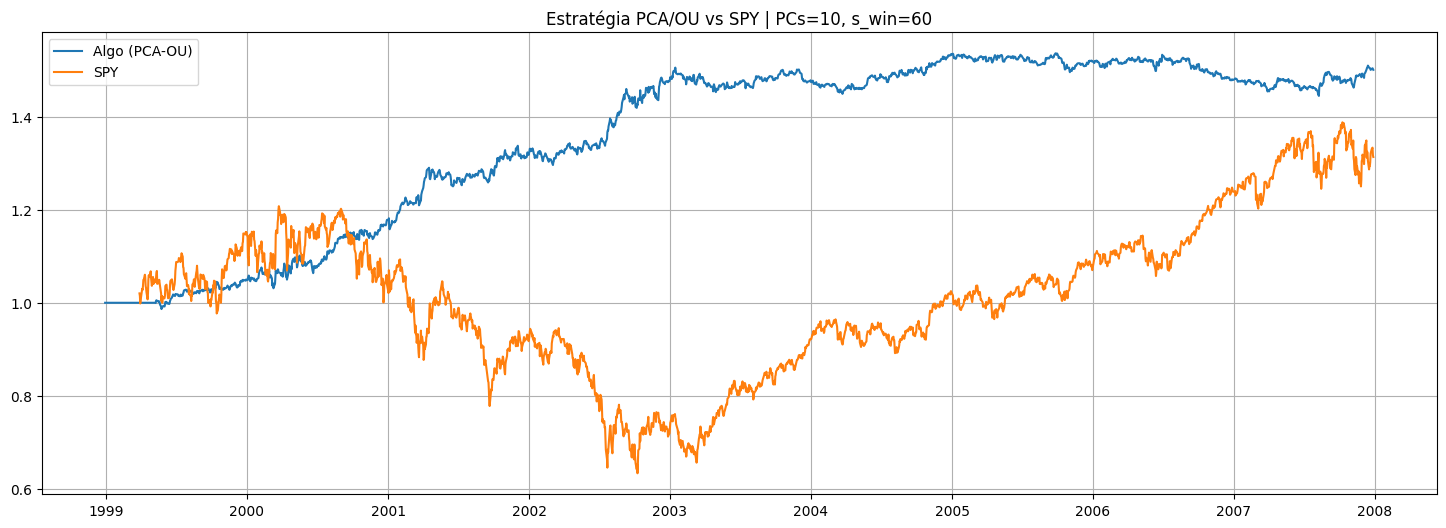

In [7]:
# Melhor
returns0 = returns.loc["1998-12-30":"2007-12-28"]
returns_spy0 = returns_spy.loc["1998-12-30":"2007-12-28"]

results2 = pca_portfolio_spy_hedge(
    returns=returns0,
    returns_spy=returns_spy0,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True
)


PERFORMANCE DA ESTRATÉGIA (1999-2007)
  CAGR      :     0.0462 (   4.62%)
  Vol       :     0.0479 (   4.79%)
  Sharpe    :     0.9651 (  96.51%)
  MaxDD     :    -0.0596 (  -5.96%)


🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 
ANÁLISE DE NEUTRALIDADE DA ESTRATÉGIA
🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 


[1/2] Calculando exposição beta agregada...

ESTATÍSTICAS DE EXPOSIÇÃO BETA AGREGADA
         Mean     Std     Min     Max  Mean_Abs
eig1  -0.0015  0.0539 -0.2478  0.2143    0.0407
eig2  -0.0007  0.0575 -0.1946  0.2754    0.0440
eig3   0.0020  0.0591 -0.2825  0.2409    0.0422
eig4   0.0033  0.0493 -0.1793  0.1481    0.0390
eig5  -0.0019  0.0528 -0.1680  0.2981    0.0402
eig6   0.0034  0.0558 -0.2179  0.2157    0.0420
eig7  -0.0030  0.0480 -0.1857  0.1384    0.0378
eig8   0.0017  0.0461 -0.1420  0.1562    0.0365
eig9   0.0033  0.0474 -0.1820  0.1834    0.0378
eig10 -0.0006  0.0467 -0.1422  0.1536    0.0372

📊 Interpretação:
  

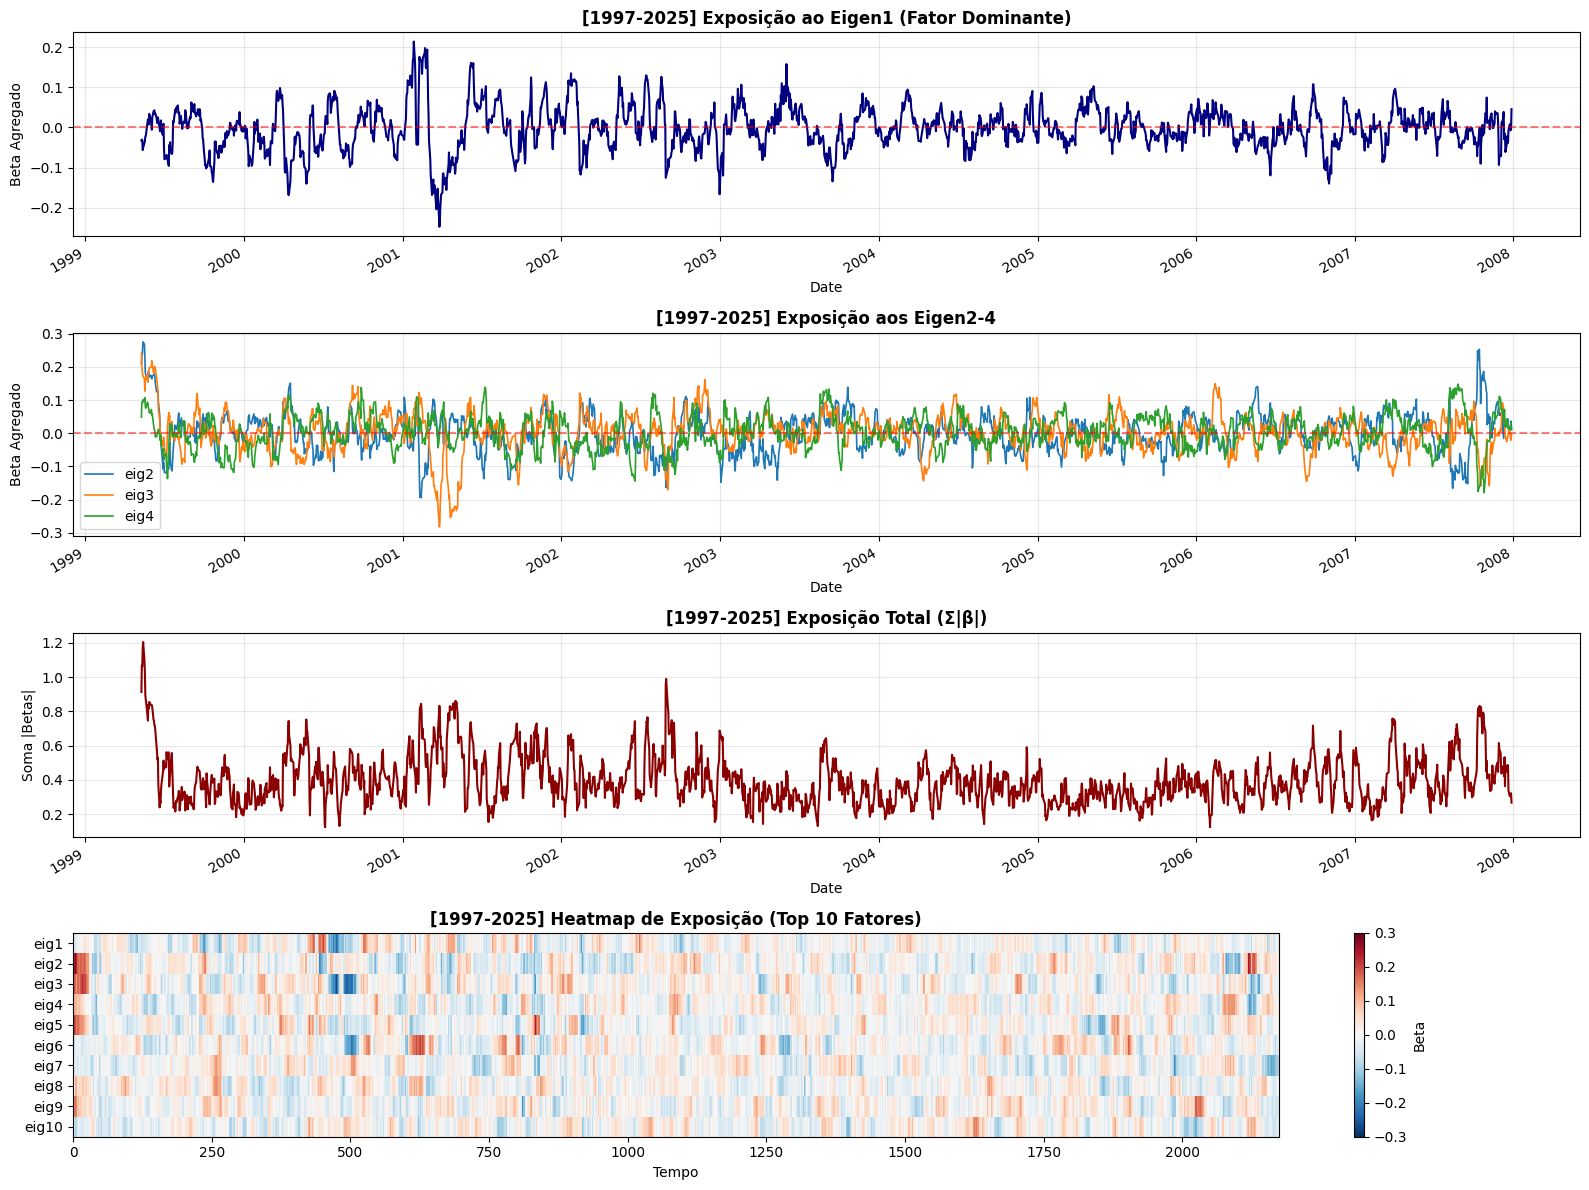


[2/2] Regredindo PnL contra fatores...

REGRESSÃO: RETORNO DA ESTRATÉGIA vs FATORES PCA
  R² (variância explicada por fatores): 0.0168 (1.68%)
  Alpha anualizado (excesso de retorno):  0.0483 (4.83%)
  Alpha diário médio:                      0.000191

  Beta médio (|valor|):                    0.0347
  Beta máximo (|valor|):                   0.1351 (fator: eig8)

📊 Interpretação:
  ✅ EXCELENTE: R² < 5% → Estratégia é genuinamente market-neutral!
     A maior parte do retorno vem de alpha idiossincrático.

  ⚠️  Alpha marginal (4.83%/ano)


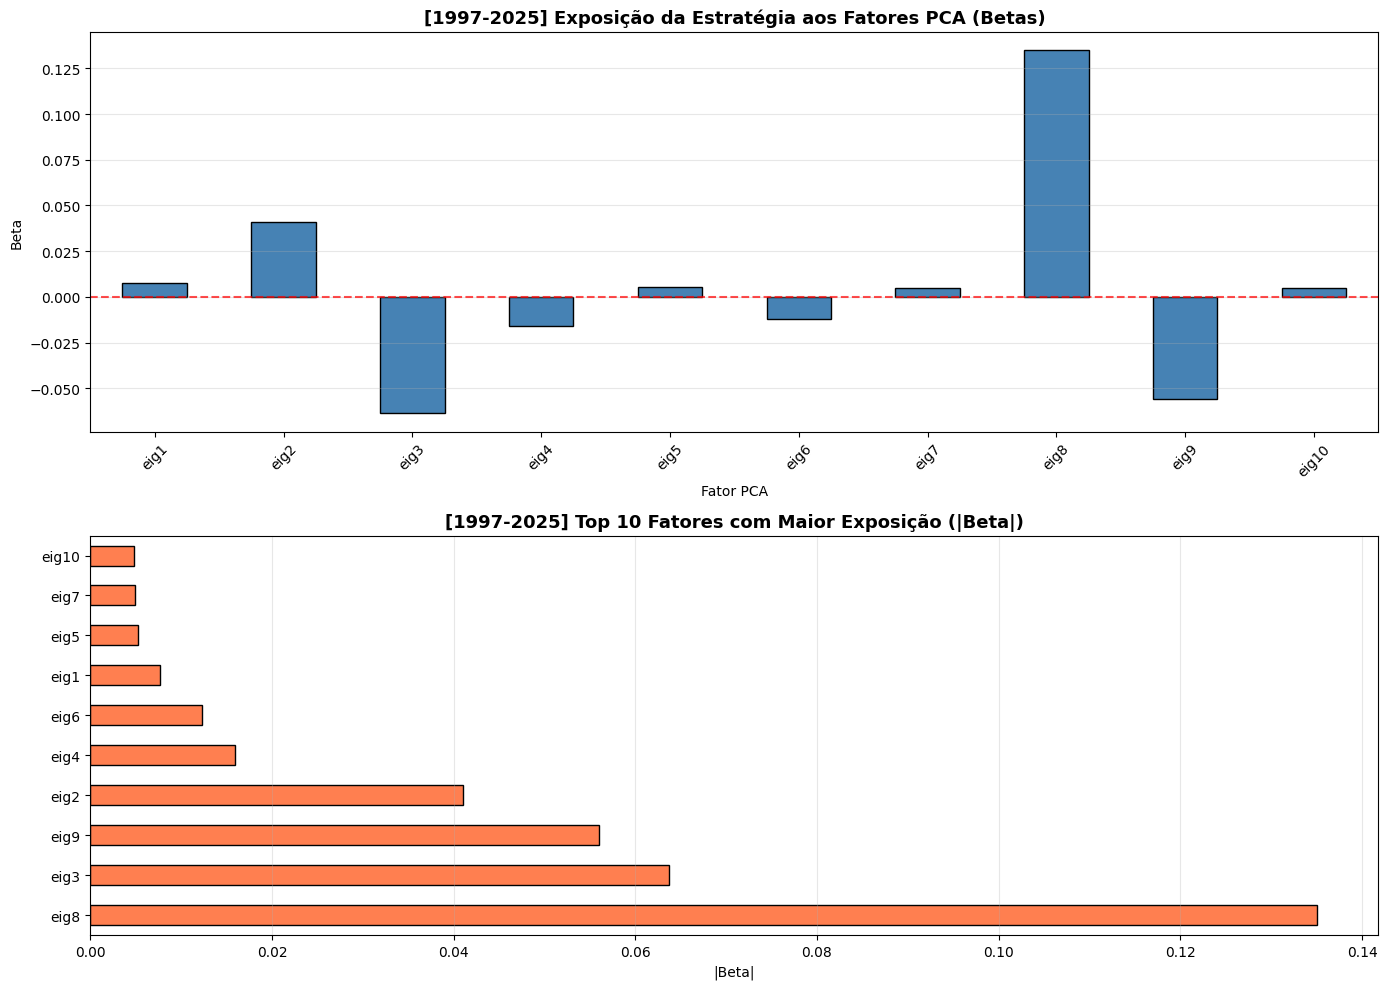


✅ Análise concluída!


📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 
ANÁLISE POR SUBPERÍODOS
📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 


Subperíodo: 1999-2002
  CAGR      :     0.1027 (  10.27%)
  Vol       :     0.0613 (   6.13%)
  Sharpe    :     1.6767 ( 167.67%)
  MaxDD     :    -0.0415 (  -4.15%)

Subperíodo: 2003-2007
  CAGR      :     0.0033 (   0.33%)
  Vol       :     0.0334 (   3.34%)
  Sharpe    :     0.0975 (   9.75%)
  MaxDD     :    -0.0596 (  -5.96%)

Subperíodo: 2008-2012
⚠️  Dados insuficientes

Subperíodo: 2013-2017
⚠️  Dados insuficientes

Subperíodo: 2018-2022
⚠️  Dados insuficientes

Subperíodo: 2023-2025
⚠️  Dados insuficientes


In [10]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net2 = results2['ret_net']
stats2 = stats_from_returns(ret_net2)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2007)")
print("="*70)
for k, v in stats2.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")

# =============================================================================
# 4. ANÁLISE DE NEUTRALIDADE ⭐ NOVO
# =============================================================================

analysis_results2 = analyze_strategy(
    algo_weights=results2['algo_weights'],
    betas=results2['betas'],
    ret_net=results2['ret_net'],
    Factor_PCA=results2['Factor_PCA'],
    pcs=results2['pcs'],
    plot=True,
    title_prefix="[1997-2025] "
)

# =============================================================================
# 5. ANÁLISE POR SUBPERÍODOS (OPCIONAL)
# =============================================================================

print("\n" + "📅 "*35)
print("ANÁLISE POR SUBPERÍODOS")
print("📅 "*35 + "\n")

subperiods2 = [
    ("1999-2002", "1999-01-01", "2002-12-31"),
    ("2003-2007", "2003-01-01", "2007-12-31"),
    ("2008-2012", "2008-01-01", "2012-12-31"),
    ("2013-2017", "2013-01-01", "2017-12-31"),
    ("2018-2022", "2018-01-01", "2022-12-31"),
    ("2023-2025", "2023-01-01", "2025-12-31"),
]

for label, start, end in subperiods2:
    print(f"\n{'='*70}")
    print(f"Subperíodo: {label}")
    print(f"{'='*70}")
    
    mask = (ret_net2.index >= start) & (ret_net2.index <= end)
    ret_sub = ret_net2[mask]
    
    if len(ret_sub) < 100:
        print("⚠️  Dados insuficientes")
        continue
    
    stats_sub = stats_from_returns(ret_sub)
    for k, v in stats_sub.items():
        print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")

## Testando com PC variáveis e Thresholdes variáveis

Tempo : 1999-03-29 00:00:00
Tempo : 1999-03-30 00:00:00
Tempo : 1999-03-31 00:00:00
Tempo : 1999-04-01 00:00:00
Tempo : 1999-04-05 00:00:00
Tempo : 1999-04-06 00:00:00
Tempo : 1999-04-07 00:00:00
Tempo : 1999-04-08 00:00:00
Tempo : 1999-04-09 00:00:00
Tempo : 1999-04-12 00:00:00
Tempo : 1999-04-13 00:00:00
Tempo : 1999-04-14 00:00:00
Tempo : 1999-04-15 00:00:00
Tempo : 1999-04-16 00:00:00
Tempo : 1999-04-19 00:00:00
Tempo : 1999-04-20 00:00:00
Tempo : 1999-04-21 00:00:00
Tempo : 1999-04-22 00:00:00
Tempo : 1999-04-23 00:00:00
Tempo : 1999-04-26 00:00:00
Tempo : 1999-04-27 00:00:00
Tempo : 1999-04-28 00:00:00
Tempo : 1999-04-29 00:00:00
Tempo : 1999-04-30 00:00:00
Tempo : 1999-05-03 00:00:00
Tempo : 1999-05-04 00:00:00
Tempo : 1999-05-05 00:00:00
Tempo : 1999-05-06 00:00:00
Tempo : 1999-05-07 00:00:00
Tempo : 1999-05-10 00:00:00
Tempo : 1999-05-11 00:00:00
Tempo : 1999-05-12 00:00:00
Tempo : 1999-05-13 00:00:00
Tempo : 1999-05-14 00:00:00
Tempo : 1999-05-17 00:00:00
Tempo : 1999-05-18 0

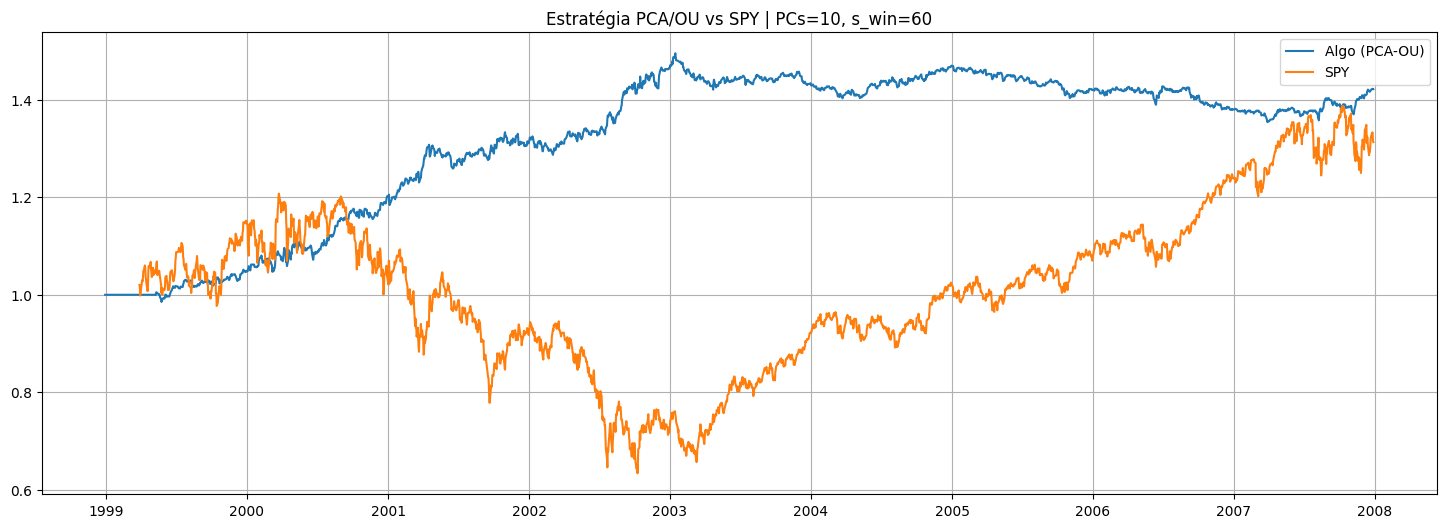

In [11]:
# Melhor
returns0 = returns.loc["1998-12-30":"2007-12-28"]
returns_spy0 = returns_spy.loc["1998-12-30":"2007-12-28"]

results3 = pca_portfolio_spy_var(
    returns=returns0,
    returns_spy=returns_spy0,
    num_pc=10,
    s_win=60,
    adaptive_thresholds=True,
    adaptive_window=252,
    percentile_open=0.10,
    percentile_close_short=0.45,
    percentile_close_long=0.50,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True
)

In [ ]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net3 = results3['ret_net']
stats3 = stats_from_returns(ret_net3)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2007)")
print("="*70)
for k, v in stats3.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")

# =============================================================================
# 4. ANÁLISE DE NEUTRALIDADE ⭐ NOVO
# =============================================================================

analysis_results3 = analyze_strategy(
    algo_weights=results3['algo_weights'],
    betas=results3['betas'],
    ret_net=results3['ret_net'],
    Factor_PCA=results3['Factor_PCA'],
    pcs=results3['pcs'],
    plot=True,
    title_prefix="[1999-2007] "
)

# =============================================================================
# 5. ANÁLISE POR SUBPERÍODOS (OPCIONAL)
# =============================================================================

print("\n" + "📅 "*35)
print("ANÁLISE POR SUBPERÍODOS")
print("📅 "*35 + "\n")

subperiods3 = [
    ("1999-2002", "1999-01-01", "2002-12-31"),
    ("2003-2007", "2003-01-01", "2007-12-31"),
]

for label, start, end in subperiods3:
    print(f"\n{'='*70}")
    print(f"Subperíodo: {label}")
    print(f"{'='*70}")
    
    mask = (ret_net3.index >= start) & (ret_net3.index <= end)
    ret_sub = ret_net3[mask]

    if len(ret_sub) < 100:
        print("⚠️  Dados insuficientes")
        continue
    
    stats_sub = stats_from_returns(ret_sub)
    for k, v in stats_sub.items():
        print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")

Tempo : 1999-03-29 00:00:00
Tempo : 1999-03-30 00:00:00
Tempo : 1999-03-31 00:00:00
Tempo : 1999-04-01 00:00:00
Tempo : 1999-04-05 00:00:00
Tempo : 1999-04-06 00:00:00
Tempo : 1999-04-07 00:00:00
Tempo : 1999-04-08 00:00:00
Tempo : 1999-04-09 00:00:00
Tempo : 1999-04-12 00:00:00
Tempo : 1999-04-13 00:00:00
Tempo : 1999-04-14 00:00:00
Tempo : 1999-04-15 00:00:00
Tempo : 1999-04-16 00:00:00
Tempo : 1999-04-19 00:00:00
Tempo : 1999-04-20 00:00:00
Tempo : 1999-04-21 00:00:00
Tempo : 1999-04-22 00:00:00
Tempo : 1999-04-23 00:00:00
Tempo : 1999-04-26 00:00:00
Tempo : 1999-04-27 00:00:00
Tempo : 1999-04-28 00:00:00
Tempo : 1999-04-29 00:00:00
Tempo : 1999-04-30 00:00:00
Tempo : 1999-05-03 00:00:00
Tempo : 1999-05-04 00:00:00
Tempo : 1999-05-05 00:00:00
Tempo : 1999-05-06 00:00:00
Tempo : 1999-05-07 00:00:00
Tempo : 1999-05-10 00:00:00
Tempo : 1999-05-11 00:00:00
Tempo : 1999-05-12 00:00:00
Tempo : 1999-05-13 00:00:00
Tempo : 1999-05-14 00:00:00
Tempo : 1999-05-17 00:00:00
Tempo : 1999-05-18 0

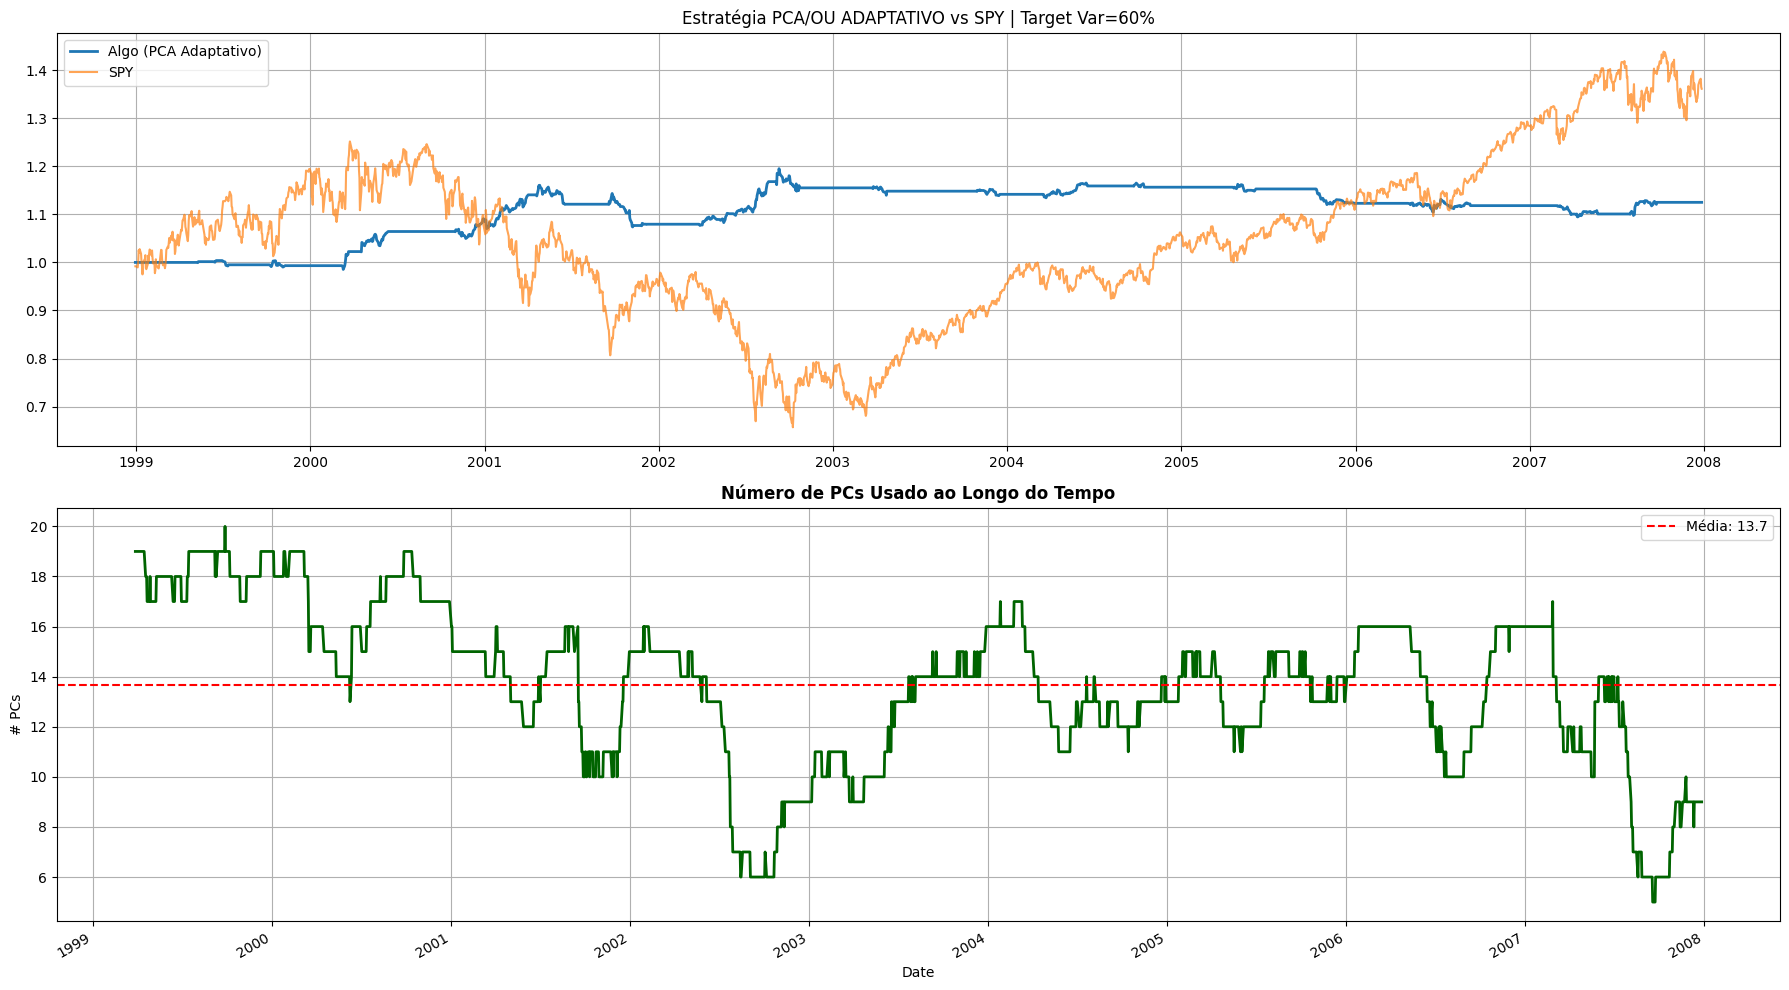

In [6]:
returns0 = returns.loc["1998-12-30":"2007-12-28"]
returns_spy0 = returns_spy.loc["1998-12-30":"2007-12-28"]

results4 = pca_portfolio_spy_adaptive_pcs(
    returns = returns0,
    returns_spy = returns_spy0,
    variance_target = 0.60,  
    min_pcs = 5,
    max_pcs = 35,
    s_win = 60,
    adaptive_thresholds = False,
    adaptive_window = 252,
    percentile_open = 0.15,
    percentile_close_short = 0.35,
    percentile_close_long = 0.45,
    # thresholds fixos
    sbo = 1.25,
    sso = 1.25,
    sbc = 0.50,
    ssc = 0.50,
    eps_cost = 0.0005,
    rebalanceamento_dias = 1,
    plot = True,
)

In [ ]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net4 = results4['ret_net']
stats4 = stats_from_returns(ret_net4)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2007)")
print("="*70)
for k, v in stats4.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")

# =============================================================================
# 4. ANÁLISE DE NEUTRALIDADE ⭐ NOVO
# =============================================================================

analysis_results4 = analyze_strategy(
    algo_weights=results4['algo_weights'],
    betas=results4['betas'],
    ret_net=results4['ret_net'],
    Factor_PCA=results4['Factor_PCA'],
    pcs=results4['pcs'],
    plot=True,
    title_prefix="[1999-2007] "
)

# =============================================================================
# 5. ANÁLISE POR SUBPERÍODOS (OPCIONAL)
# =============================================================================

print("\n" + "📅 "*35)
print("ANÁLISE POR SUBPERÍODOS")
print("📅 "*35 + "\n")

subperiods4 = [
    ("1999-2002", "1999-01-01", "2002-12-31"),
    ("2003-2007", "2003-01-01", "2007-12-31"),
]

for label, start, end in subperiods4:
    print(f"\n{'='*70}")
    print(f"Subperíodo: {label}")
    print(f"{'='*70}")
    
    mask = (ret_net4.index >= start) & (ret_net4.index <= end)
    ret_sub = ret_net4[mask]

    if len(ret_sub) < 100:
        print("⚠️  Dados insuficientes")
        continue
    
    stats_sub = stats_from_returns(ret_sub)
    for k, v in stats_sub.items():
        print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")

Tempo : 1999-03-29 00:00:00
Tempo : 1999-03-30 00:00:00
Tempo : 1999-03-31 00:00:00
Tempo : 1999-04-01 00:00:00
Tempo : 1999-04-05 00:00:00
Tempo : 1999-04-06 00:00:00
Tempo : 1999-04-07 00:00:00
Tempo : 1999-04-08 00:00:00
Tempo : 1999-04-09 00:00:00
Tempo : 1999-04-12 00:00:00
Tempo : 1999-04-13 00:00:00
Tempo : 1999-04-14 00:00:00
Tempo : 1999-04-15 00:00:00
Tempo : 1999-04-16 00:00:00
Tempo : 1999-04-19 00:00:00
Tempo : 1999-04-20 00:00:00
Tempo : 1999-04-21 00:00:00
Tempo : 1999-04-22 00:00:00
Tempo : 1999-04-23 00:00:00
Tempo : 1999-04-26 00:00:00
Tempo : 1999-04-27 00:00:00
Tempo : 1999-04-28 00:00:00
Tempo : 1999-04-29 00:00:00
Tempo : 1999-04-30 00:00:00
Tempo : 1999-05-03 00:00:00
Tempo : 1999-05-04 00:00:00
Tempo : 1999-05-05 00:00:00
Tempo : 1999-05-06 00:00:00
Tempo : 1999-05-07 00:00:00
Tempo : 1999-05-10 00:00:00
Tempo : 1999-05-11 00:00:00
Tempo : 1999-05-12 00:00:00
Tempo : 1999-05-13 00:00:00
Tempo : 1999-05-14 00:00:00
Tempo : 1999-05-17 00:00:00
Tempo : 1999-05-18 0

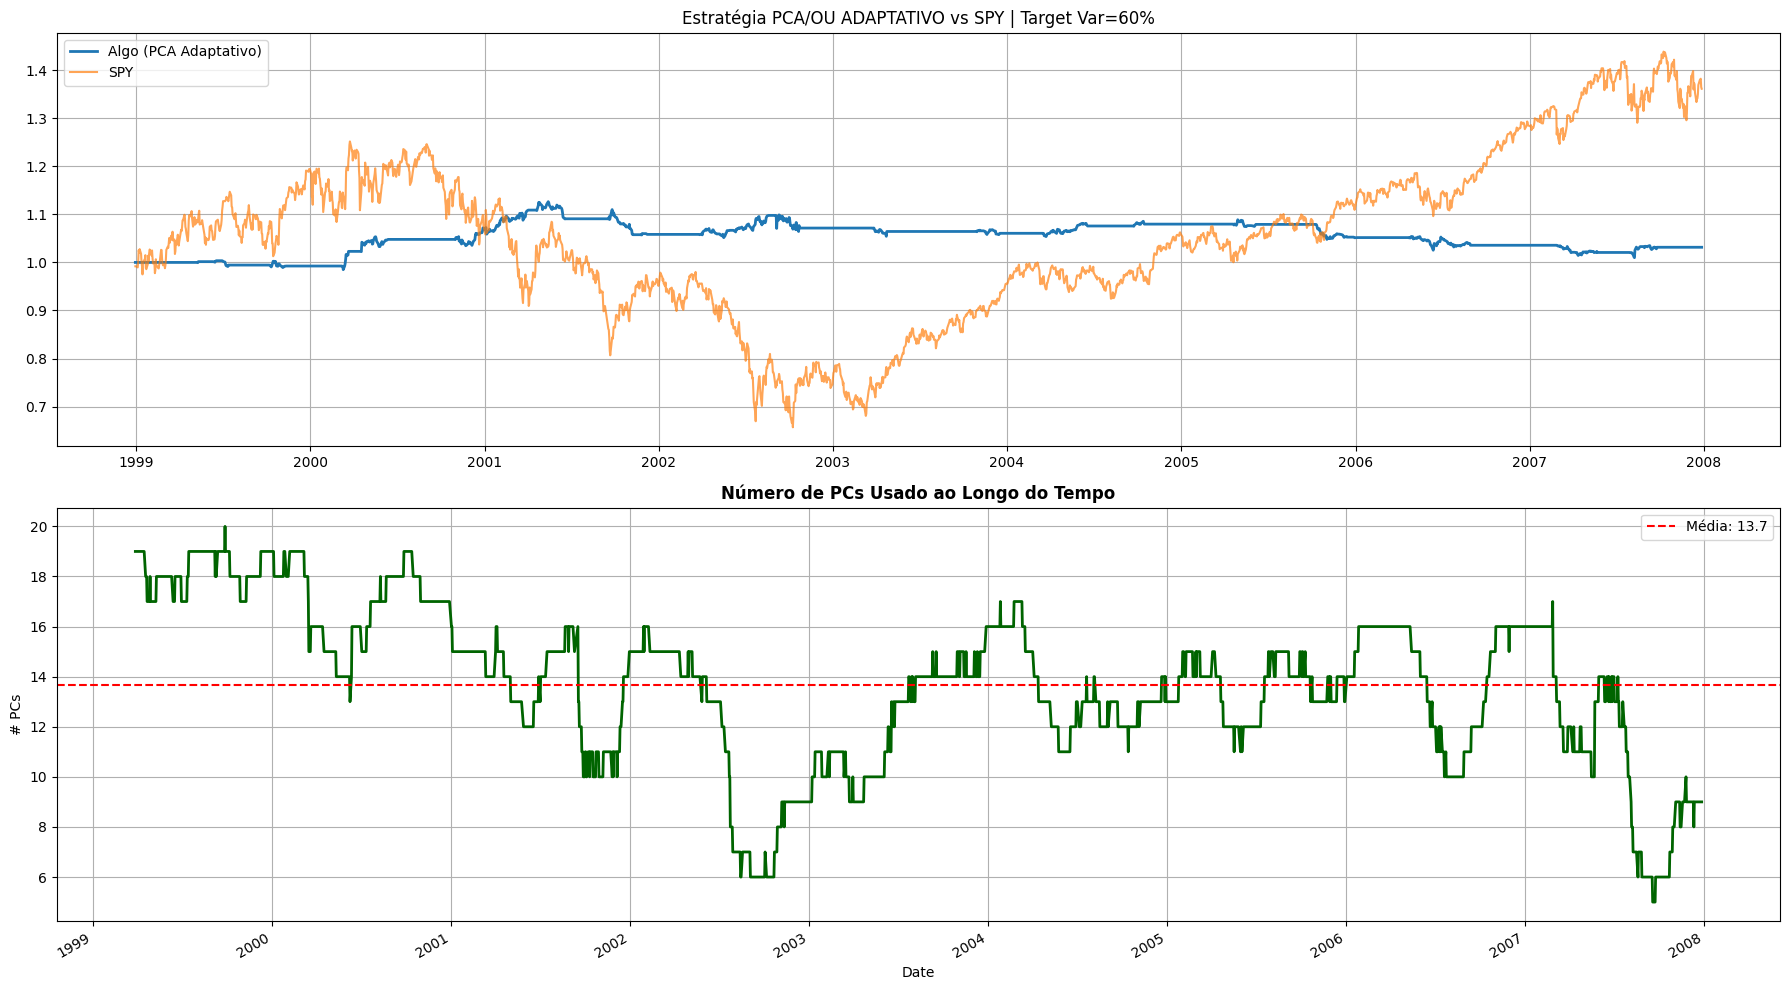

In [15]:
returns0 = returns.loc["1998-12-30":"2007-12-28"]
returns_spy0 = returns_spy.loc["1998-12-30":"2007-12-28"]

results5 = pca_portfolio_spy_adaptive_pcs(
    returns = returns0,
    returns_spy = returns_spy0,
    variance_target = 0.60,  
    min_pcs = 5,
    max_pcs = 35,
    s_win = 60,
    adaptive_thresholds = True,
    adaptive_window = 252,
    percentile_open = 0.15,
    percentile_close_short = 0.35,
    percentile_close_long = 0.45,
    # thresholds fixos
    sbo = 1.25,
    sso = 1.25,
    sbc = 0.50,
    ssc = 0.50,
    eps_cost = 0.0005,
    rebalanceamento_dias = 1,
    plot = True,
)

### Longo prazo

In [16]:
# Carregar dados
#start_date = "1997-01-02"
#end_date = "2007-12-31"

data_longa = pd.read_csv("dados_1997_2025.csv", index_col=0)
returns_longa = data_longa.pct_change()

returns_longa.dropna(inplace=True,axis=0, how='all')
returns_longa.dropna(inplace=True,axis=1, how='any')

data_spy_longa = yf.download("SPY", start="1997-01-02", end="2025-12-31", auto_adjust=True)["Close"]
data_spy_longa.index = pd.to_datetime(data_spy_longa.index)
data_spy_longa = data_spy_longa.sort_index()

# Garantir que ambos os DataFrames tenham índices coerentes e ordenados (sem timezone)
returns_spy_longa = data_spy_longa.pct_change()
returns_longa.index     = pd.to_datetime(returns_longa.index).tz_localize(None)
returns_spy_longa.index = pd.to_datetime(returns_spy_longa.index).tz_localize(None)
returns_longa     = returns_longa.sort_index()
returns_spy_longa = returns_spy_longa.sort_index()

C:\Users\savio\AppData\Local\Temp\ipykernel_13128\156121036.py:6: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_longa = data_longa.pct_change()
[*********************100%***********************]  1 of 1 completed


Tempo : 1997-04-01 00:00:00
Tempo : 1997-04-02 00:00:00
Tempo : 1997-04-03 00:00:00
Tempo : 1997-04-04 00:00:00
Tempo : 1997-04-07 00:00:00
Tempo : 1997-04-08 00:00:00
Tempo : 1997-04-09 00:00:00
Tempo : 1997-04-10 00:00:00
Tempo : 1997-04-11 00:00:00
Tempo : 1997-04-14 00:00:00
Tempo : 1997-04-15 00:00:00
Tempo : 1997-04-16 00:00:00
Tempo : 1997-04-17 00:00:00
Tempo : 1997-04-18 00:00:00
Tempo : 1997-04-21 00:00:00
Tempo : 1997-04-22 00:00:00
Tempo : 1997-04-23 00:00:00
Tempo : 1997-04-24 00:00:00
Tempo : 1997-04-25 00:00:00
Tempo : 1997-04-28 00:00:00
Tempo : 1997-04-29 00:00:00
Tempo : 1997-04-30 00:00:00
Tempo : 1997-05-01 00:00:00
Tempo : 1997-05-02 00:00:00
Tempo : 1997-05-05 00:00:00
Tempo : 1997-05-06 00:00:00
Tempo : 1997-05-07 00:00:00
Tempo : 1997-05-08 00:00:00
Tempo : 1997-05-09 00:00:00
Tempo : 1997-05-12 00:00:00
Tempo : 1997-05-13 00:00:00
Tempo : 1997-05-14 00:00:00
Tempo : 1997-05-15 00:00:00
Tempo : 1997-05-16 00:00:00
Tempo : 1997-05-19 00:00:00
Tempo : 1997-05-20 0

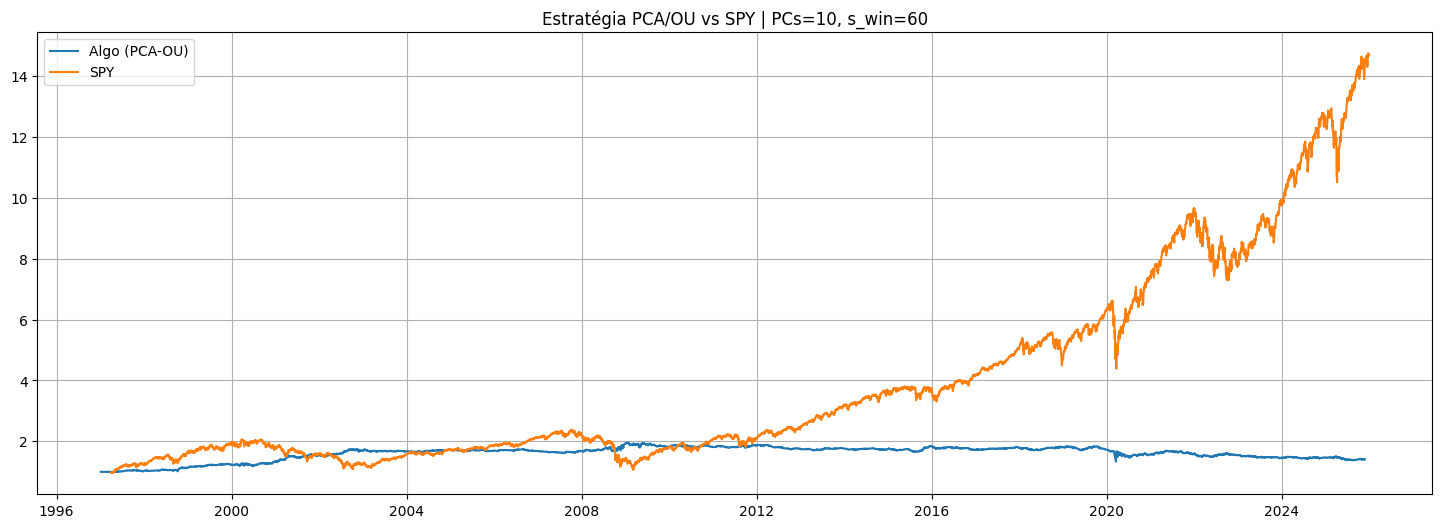

In [17]:
# Melhor longo

results6 = pca_portfolio_spy(
    returns=returns_longa,
    returns_spy=returns_spy_longa,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True
)


PERFORMANCE DA ESTRATÉGIA (1997-2025)
  CAGR      :     0.0119 (   1.19%)
  Vol       :     0.0739 (   7.39%)
  Sharpe    :     0.1614 (  16.14%)
  MaxDD     :    -0.3192 ( -31.92%)


🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 
ANÁLISE DE NEUTRALIDADE DA ESTRATÉGIA
🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 


[1/2] Calculando exposição beta agregada...

ESTATÍSTICAS DE EXPOSIÇÃO BETA AGREGADA
         Mean     Std     Min     Max  Mean_Abs
eig1   0.0011  0.0688 -0.5132  0.4448    0.0487
eig2  -0.0031  0.0832 -0.3985  0.4903    0.0596
eig3   0.0009  0.0743 -0.3152  0.3800    0.0552
eig4   0.0030  0.0572 -0.2219  0.2446    0.0447
eig5   0.0040  0.0596 -0.2256  0.2597    0.0454
eig6  -0.0013  0.0604 -0.2577  0.2768    0.0463
eig7  -0.0056  0.0602 -0.3659  0.2327    0.0457
eig8  -0.0004  0.0584 -0.2659  0.2560    0.0440
eig9  -0.0016  0.0572 -0.2526  0.3032    0.0436
eig10  0.0034  0.0565 -0.2441  0.4926    0.0436

📊 Interpretação:
  

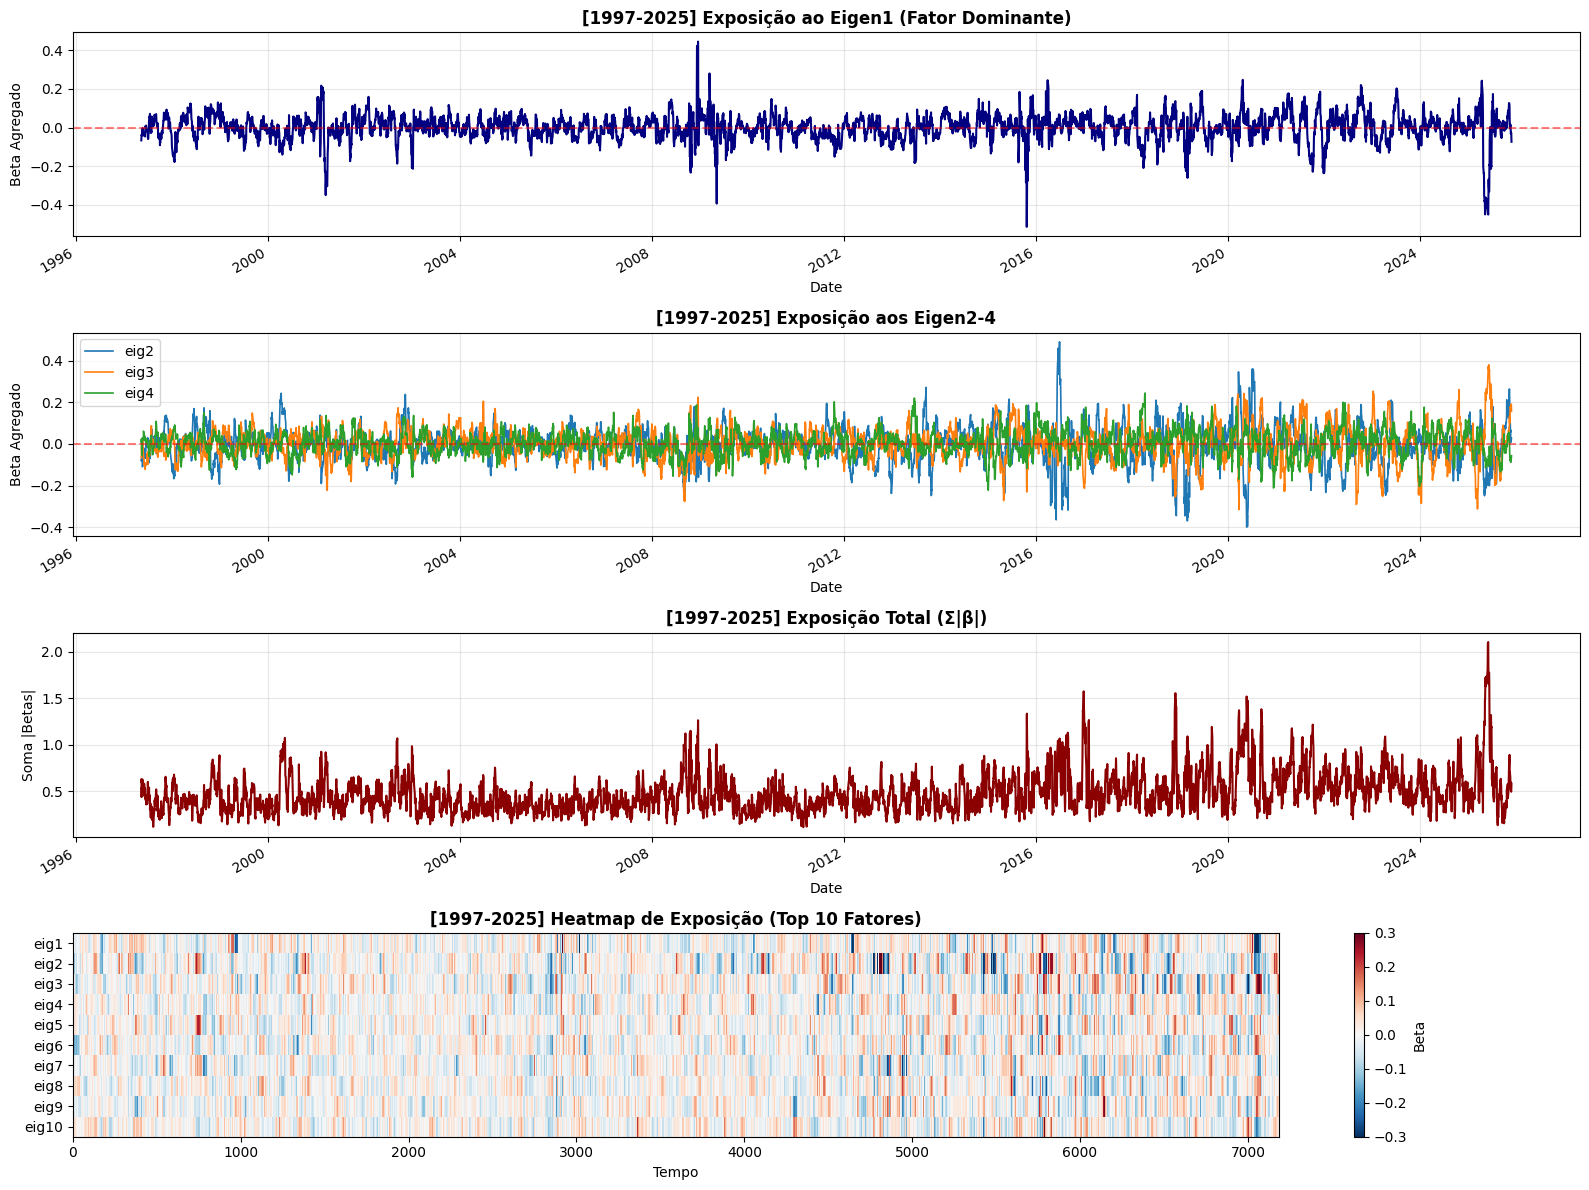


[2/2] Regredindo PnL contra fatores...

REGRESSÃO: RETORNO DA ESTRATÉGIA vs FATORES PCA
  R² (variância explicada por fatores): 0.0136 (1.36%)
  Alpha anualizado (excesso de retorno):  0.0160 (1.60%)
  Alpha diário médio:                      0.000063

  Beta médio (|valor|):                    0.0443
  Beta máximo (|valor|):                   0.0798 (fator: eig5)

📊 Interpretação:
  ✅ EXCELENTE: R² < 5% → Estratégia é genuinamente market-neutral!
     A maior parte do retorno vem de alpha idiossincrático.

  ⚠️  Alpha marginal (1.60%/ano)


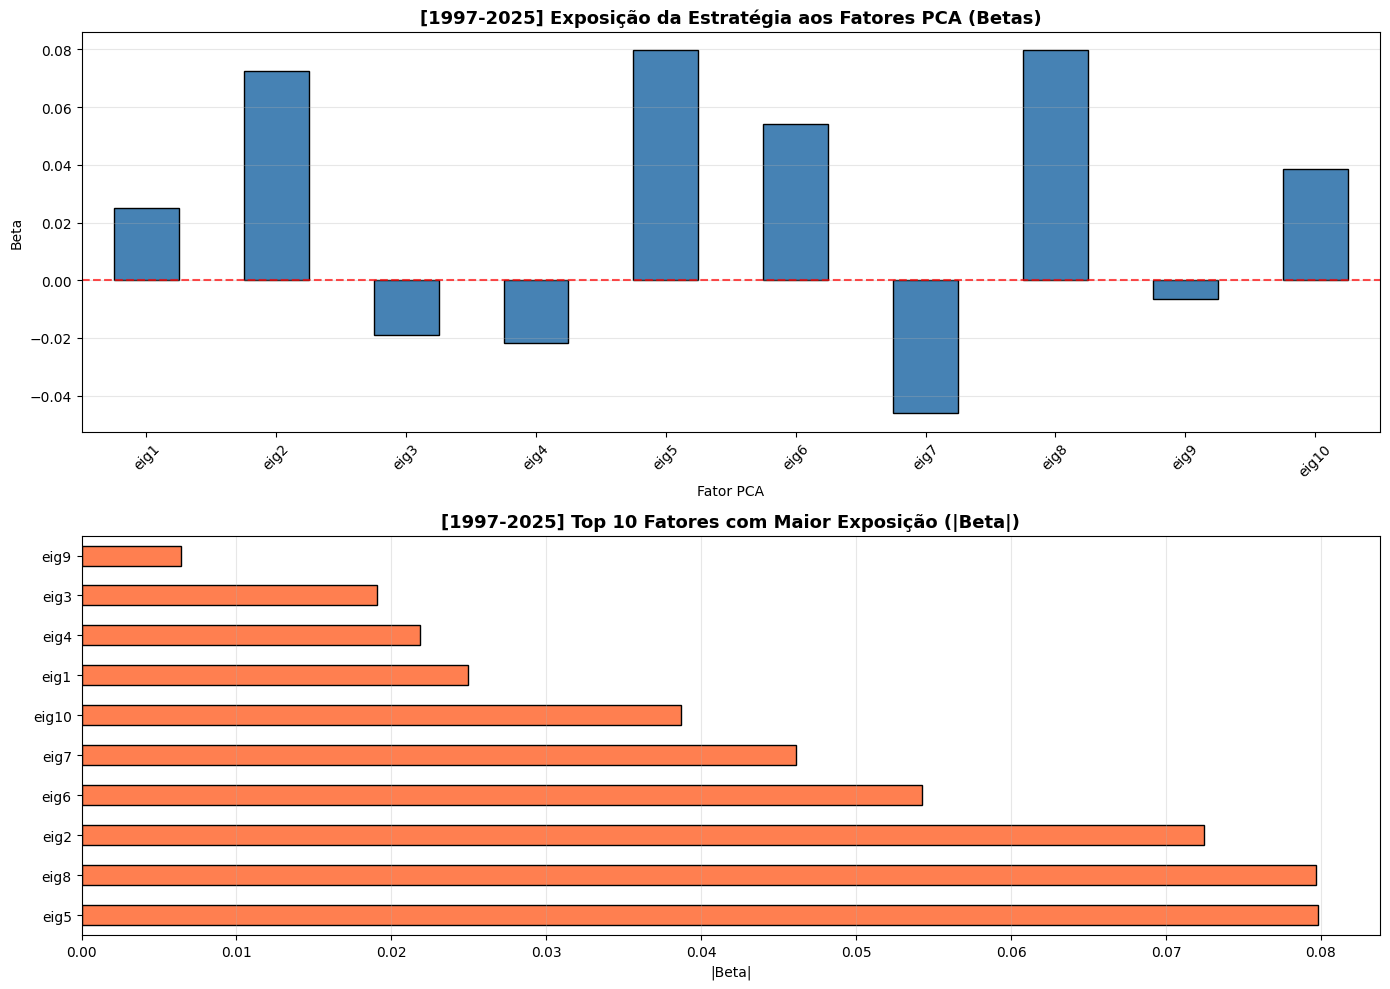


✅ Análise concluída!


📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 
ANÁLISE POR SUBPERÍODOS
📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 


Subperíodo: 1997-2002
  CAGR      :     0.0925 (   9.25%)
  Vol       :     0.0766 (   7.66%)
  Sharpe    :     1.2069 ( 120.69%)
  MaxDD     :    -0.0799 (  -7.99%)

Subperíodo: 2003-2007
  CAGR      :    -0.0022 (  -0.22%)
  Vol       :     0.0395 (   3.95%)
  Sharpe    :    -0.0564 (  -5.64%)
  MaxDD     :    -0.0795 (  -7.95%)

Subperíodo: 2008-2012
  CAGR      :     0.0094 (   0.94%)
  Vol       :     0.0893 (   8.93%)
  Sharpe    :     0.1057 (  10.57%)
  MaxDD     :    -0.1155 ( -11.55%)

Subperíodo: 2013-2019
  CAGR      :    -0.0024 (  -0.24%)
  Vol       :     0.0477 (   4.77%)
  Sharpe    :    -0.0497 (  -4.97%)
  MaxDD     :    -0.0796 (  -7.96%)

Subperíodo: 2020-2025
  CAGR      :    -0.0344 (  -3.44%)
  Vol       :     0.1000 (  10.00%)
  Sharpe    :    -0.3438 ( -34.38%)
  MaxDD   

In [18]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net6 = results6['ret_net']
stats6 = stats_from_returns(ret_net6)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1997-2025)")
print("="*70)
for k, v in stats6.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")

# =============================================================================
# 4. ANÁLISE DE NEUTRALIDADE ⭐
# =============================================================================

analysis_results6 = analyze_strategy(
    algo_weights=results6['algo_weights'],
    betas=results6['betas'],
    ret_net=results6['ret_net'],
    Factor_PCA=results6['Factor_PCA'],
    pcs=results6['pcs'],
    plot=True,
    title_prefix="[1997-2025] "
)

# =============================================================================
# 5. ANÁLISE POR SUBPERÍODOS (OPCIONAL)
# =============================================================================

print("\n" + "📅 "*35)
print("ANÁLISE POR SUBPERÍODOS")
print("📅 "*35 + "\n")

subperiods6 = [
    ("1997-2002", "1997-01-01", "2002-12-31"),
    ("2003-2007", "2003-01-01", "2007-12-31"),
    ("2008-2012", "2008-01-01", "2012-12-31"),
    ("2013-2019", "2013-01-01", "2019-12-31"),
    ("2020-2025", "2020-01-01", "2025-12-31"),
]

for label, start, end in subperiods6:
    print(f"\n{'='*70}")
    print(f"Subperíodo: {label}")
    print(f"{'='*70}")
    
    mask = (ret_net6.index >= start) & (ret_net6.index <= end)
    ret_sub = ret_net6[mask]

    if len(ret_sub) < 100:
        print("⚠️  Dados insuficientes")
        continue
    
    stats_sub = stats_from_returns(ret_sub)
    for k, v in stats_sub.items():
        print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")

In [ ]:
#pip install quantstats

In [ ]:
import quantstats as qs

#qs.reports.html(cum_algo, output="relatorio.html", title="Relatório da Estratégia")
